# Laboratorio 3 – Clasificación: SmartAlpes
### **Grupo: 33** (Carolina Chinchilla & William Pollock)

## Preparación del entorno

### Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from IPython.display import Markdown, display

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 1

### Carga de los datos

In [2]:
data_raw = pd.read_csv('Datos_Laboratorio3.csv', sep=';', encoding='latin-1')
data = data_raw.copy()
data.head()

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Horas_sueño,Entrenamiento_preferido,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,Funcional,3,98,0,0,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,Funcional,4,105,0,0,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,Fuerza,1,88,0,0,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,Funcional,5,96,0,0,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,Balance,3,120,0,1,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


In [3]:
data.shape

(9698, 26)

El conjunto tiene **9,698 registros y 26 columnas** (24 atributos y 2 variables objetivo: 'Plan_entrenamiento' y 'Plan_nutrición').

## 1. Exploración de los datos y propuesta de limpieza y preparación

En esta sección exploramos el conjunto de datos para identificar problemas de calidad, outliers y características relevantes, y luego aplicamos la propuesta de limpieza y preparación justificada en los hallazgos.

### 1.1 Exploración de los datos


#### 1.1.1 Tipos de variables y estadísticas descriptivas

In [4]:
data.dtypes

Edad                         int64
Gnereo                         str
Peso                       float64
Altura                     float64
BMI                        float64
Objetivo                       str
Condicion_salud                str
Nivel_Actividad                str
Nivel_experiencia              str
Dieta_preferida                str
Horas_sueño                float64
Entrenamiento_preferido        str
Cantidad_equipo              int64
Tiempo_disponible            int64
Tiene_alergia                int64
Problemas_digestivos         int64
Fumador                      int64
Cigarrillos_dia            float64
Alcohol                      int64
Alcohol_semana             float64
Score_micronutrientes      float64
Ingesta_proteinas          float64
Pasos_dia                    int64
Ingesta_agua               float64
Plan_entrenamiento             str
Plan_nutrición                 str
dtype: object

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,9698.0,45.112601,17.641045,15.00,30.00,45.00,61.00,75.00
Peso,9687.0,92.622515,27.383913,45.00,68.80,92.60,116.50,140.00
Altura,9698.0,1.775047,0.158754,1.50,1.64,1.78,1.91,2.05
BMI,9698.0,30.131391,10.605675,10.93,21.62,29.19,37.06,62.09
Horas_sueño,9698.0,7.004382,1.449454,0.00,5.80,7.00,8.20,23.00
Cantidad_equipo,9698.0,2.988039,2.018493,0.00,1.00,3.00,5.00,6.00
Tiempo_disponible,9698.0,67.194061,30.839475,15.00,40.00,67.00,94.00,120.00
Tiene_alergia,9698.0,0.201588,0.401207,0.00,0.00,0.00,0.00,1.00
Problemas_digestivos,9698.0,0.153846,0.360820,0.00,0.00,0.00,0.00,1.00
Fumador,9698.0,0.227366,0.419153,0.00,0.00,0.00,0.00,1.00


#### 1.1.2 Valores faltantes y duplicados

In [6]:
print('Valores nulos por columna:')
display(data.isna().sum()[data.isna().sum() > 0])
print(f'\nFilas duplicadas: {data.duplicated().sum()}')



Valores nulos por columna:


Peso    11
dtype: int64


Filas duplicadas: 0


**Observaciones:**
- Solo la columna 'Peso' tiene valores nulos (**11 registros**).
- **No hay filas duplicadas**, lo cual es positivo.

Aprovechando que existe la relación 'BMI = Peso / Altura^2', podremos imputar el peso faltante a partir del BMI y la altura.

#### 1.1.3 Análisis de variables categóricas

Revisamos la distribución de cada variable categórica para detectar inconsistencias en las etiquetas (typos, categorías no documentadas, etc.).


In [7]:
cat_cols = ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad',
            'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido',
            'Plan_entrenamiento', 'Plan_nutrición']

for c in cat_cols:
    print(f'--- {c} ---')
    print(data[c].value_counts(dropna=False))
    print()


--- Gnereo ---
Gnereo
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64

--- Objetivo ---
Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64

--- Condicion_salud ---
Condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64

--- Nivel_Actividad ---
Nivel_Actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64

--- Nivel_experiencia ---
Nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64

--- Dieta_preferida ---
Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64

--- Entrenamiento_prefer

**Hallazgos importantes en las categóricas:**

| Columna | Problema detectado | Decisión |
|---|---|---|
| Gnereo | La columna está escrita con un **typo** (debe ser género) | Renombrar a 'Genero' |
| Objetivo | Tiene **4 registros con valor 'grasa'** que claramente corresponden a 'Perdida grasa' | Reemplazar 'grasa' con'Perdida grasa' |
| Dieta_preferida | Tiene **11 registros con valor 'Animal'**, que no está en el diccionario. Dado que describe una dieta no vegetariana, se asume equivalente a 'No-Vegetariano' | Reemplazar 'Animal' con 'No-Vegetariano. |

**Desbalance de clases en las variables objetivo:**
- 'Plan_entrenamiento': 'Ninguno' (3,807), 'Medio' (2,945), 'Bajo' (2,290), 'Alto' (656) --> la clase 'Alto' representa solo  alrededor de 6.8%
- 'Plan_nutrición': 'Balanceado' (4,297), 'Sin plan' (2,522), 'Basico' (2,287), 'Especializado' (592) --> la clase 'Especializado' es minoritaria (aprox. 6.1 %)

Esto implica que debemos utilizar **métricas robustas al desbalance** (F1-score, especialmente f1_macro`') y considerar **estratificar** la partición train/test.

#### 1.1.4 Análisis de variables numéricas (outliers y consistencia)

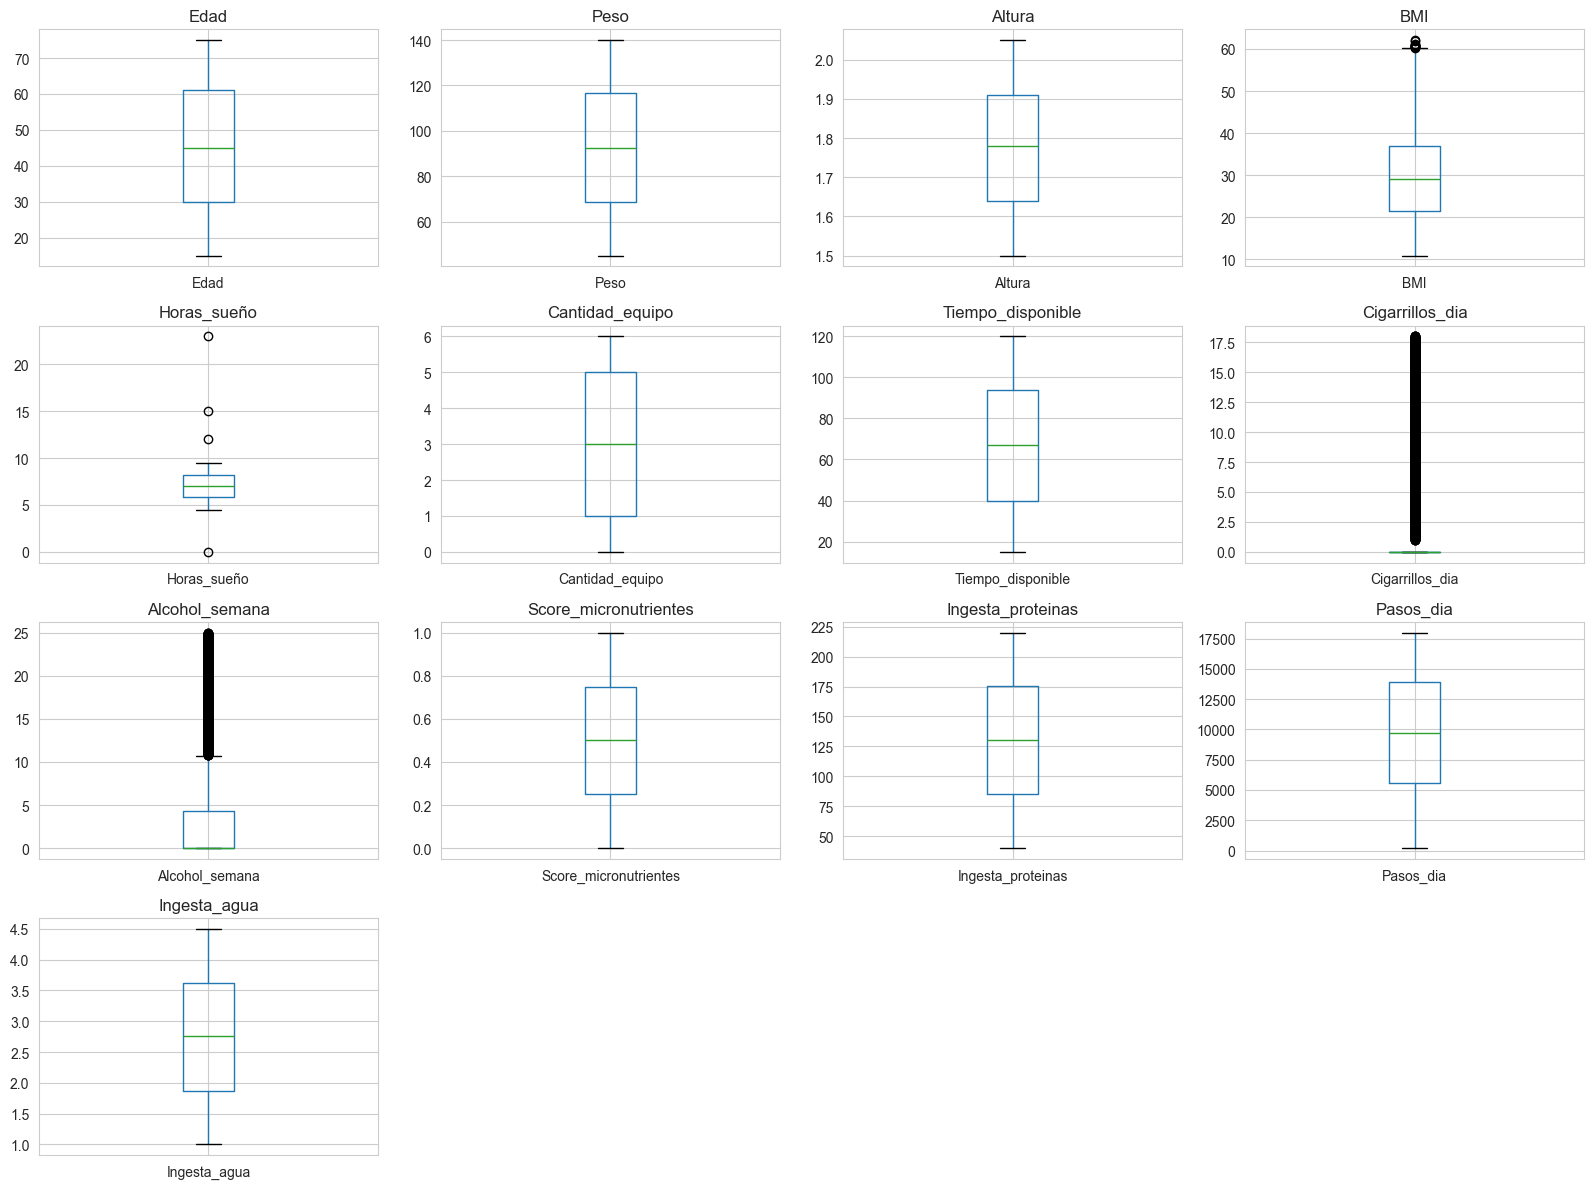

In [8]:
num_cols = ['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueño',
            'Cantidad_equipo', 'Tiempo_disponible', 'Cigarrillos_dia',
            'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas',
            'Pasos_dia', 'Ingesta_agua']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, c in zip(axes.flatten(), num_cols):
    data.boxplot(column=c, ax=ax)
    ax.set_title(c)
for ax in axes.flatten()[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
print('Horas_sueño > 15:', (data['Horas_sueño'] > 15).sum(), 'valores')
print('Horas_sueño < 3:', (data['Horas_sueño'] < 3).sum(), 'valores')
print()
print(data[data['Horas_sueño'] > 15][['Edad','Horas_sueño']])



Horas_sueño > 15: 1 valores
Horas_sueño < 3: 1 valores

      Edad  Horas_sueño
2250    46         23.0


Se observa **1 registro con 'Horas_sueño = 23'**, lo cual es altamente inusual. Lo trataremos como un error de captura (muy probablemente 2.3 h o simplemente un dato inválido).

#### 1.1.5 Verificación de consistencia entre variables binarias y sus magnitudes

Las variables binarias 'Fumador' y 'Alcohol' deberían ser coherentes con 'Cigarrillos_dia' y 'Alcohol_semana' respectivamente:


In [10]:
print('Fumador=1 pero Cigarrillos_dia=0:',
      ((data['Fumador']==1) & (data['Cigarrillos_dia']==0)).sum())
print('Fumador=0 pero Cigarrillos_dia>0:',
      ((data['Fumador']==0) & (data['Cigarrillos_dia']>0)).sum())
print('Alcohol=1 pero Alcohol_semana=0:',
      ((data['Alcohol']==1) & (data['Alcohol_semana']==0)).sum())
print('Alcohol=0 pero Alcohol_semana>0:',
      ((data['Alcohol']==0) & (data['Alcohol_semana']>0)).sum())



Fumador=1 pero Cigarrillos_dia=0: 0
Fumador=0 pero Cigarrillos_dia>0: 0
Alcohol=1 pero Alcohol_semana=0: 0
Alcohol=0 pero Alcohol_semana>0: 0


**Las variables son internamente consistentes**. Esto también implica que 'Fumador' es redundante respecto a 'Cigarrillos_dia'. Lo mismo ocurre con 'Alcohol' y 'Alcohol_semana'. Sin embargo, mantenerlas no afecta negativamente al modelo y pueden ayudar a algoritmos lineales a separar "fumadores vs no fumadores" como categoría explícita.


#### 1.1.6 Verificación de la relación BMI = Peso / Altura^2

In [11]:
calc_bmi = data['Peso'] / (data['Altura'] ** 2)
diff = (calc_bmi - data['BMI']).abs()
print(f'Diferencia promedio entre BMI calculado y reportado: {diff.mean():.4f}')
print(f'Diferencia máxima: {diff.max():.4f}')

Diferencia promedio entre BMI calculado y reportado: 0.0025
Diferencia máxima: 0.0050


Las diferencias son despreciables, lo que confirma que 'BMI' se calcula directamente de 'Peso' y 'Altura'. Esto tiene dos implicaciones:

1. Podemos **imputar los pesos faltantes** con 'Peso = BMI × Altura^2'.
2. 'BMI' es una **variable derivada** (introduce redundancia con 'Peso' y 'Altura'). En modelos lineales esto puede causar multicolinealidad, la regularización L1/L2 lo mitigará.


#### 1.1.7 Distribución de las variables objetivo

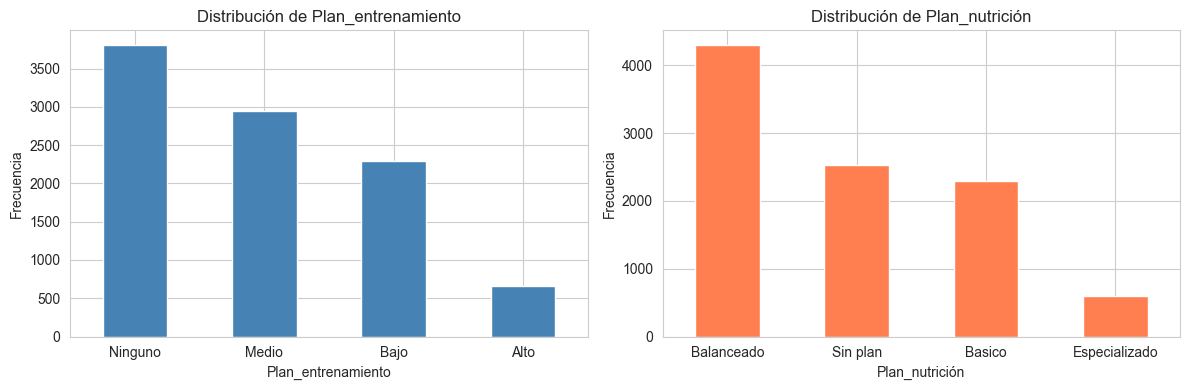

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['Plan_entrenamiento'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de Plan_entrenamiento')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

data['Plan_nutrición'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribución de Plan_nutrición')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

#### 1.1.8 Relación entre las dos variables objetivo

Plan_nutrición      Balanceado  Basico  Especializado  Sin plan
Plan_entrenamiento                                             
Alto                       388     107             73        88
Bajo                      1050     541            162       537
Medio                     1468     665            233       579
Ninguno                   1391     974            124      1318


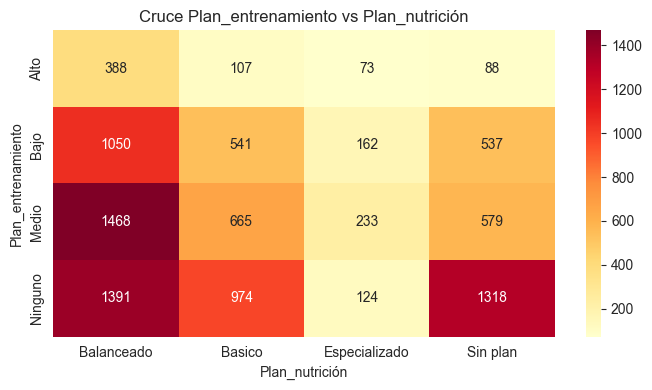

In [13]:
cross = pd.crosstab(data['Plan_entrenamiento'], data['Plan_nutrición'])
print(cross)

plt.figure(figsize=(7, 4))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Cruce Plan_entrenamiento vs Plan_nutrición')
plt.tight_layout()
plt.show()

El cruce revela que los planes **no son independientes** (por ejemplo, el plan 'Alto' de entrenamiento se asocia principalmente con planes de nutrición 'Balanceado' o 'Especializado'). Esto es consistente con la intuición de negocio (quienes entrenan intensamente suelen requerir planes nutricionales más elaborados).

#### 1.1.9 Correlación entre variables numéricas

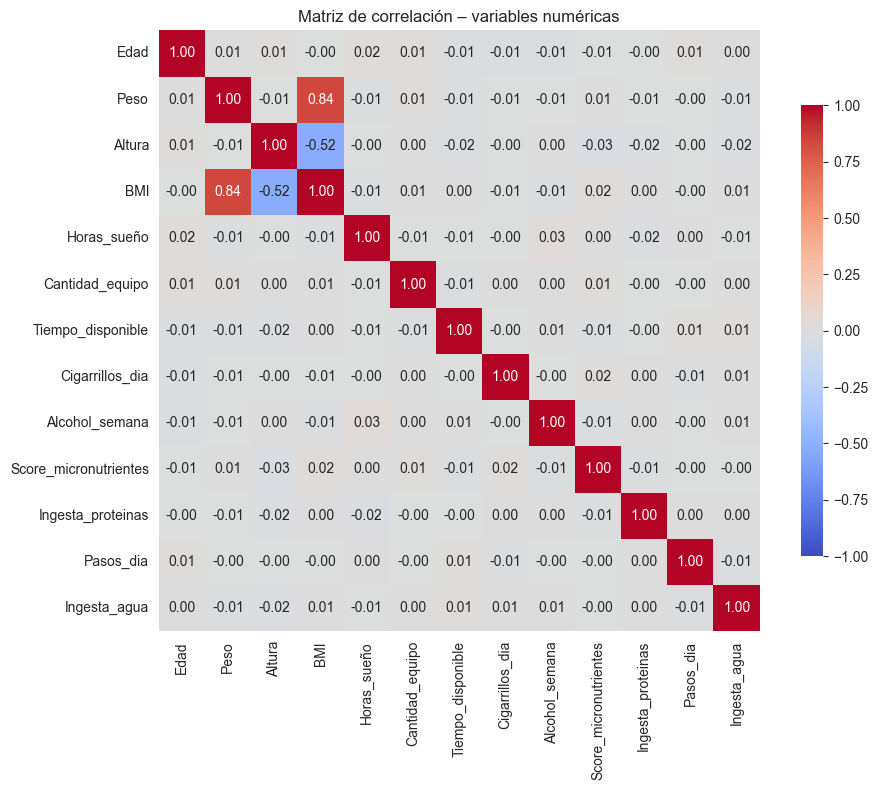

In [14]:
plt.figure(figsize=(10, 8))
corr = data[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.75})
plt.title('Matriz de correlación – variables numéricas')
plt.tight_layout()
plt.show()

La correlación más fuerte es entre 'Peso' y 'BMI'. El resto de las variables numéricas están prácticamente descorrelacionadas entre sí.

### 1.2 Propuesta de limpieza y preparación

Con base en la exploración anterior, aplicamos las siguientes transformaciones. Todas se justifican a partir de los hallazgos de la sección 1.1.

| # | Problema | Transformación | Justificación |
|---|---|---|---|
| 1 | Typo en nombre de columna 'Gnereo' | Renombrar a 'Genero' | El diccionario define el nombre correcto como "Género" |
| 2 | Caracteres especiales en nombres ('Horas_sueño', 'Plan_nutrición') | Renombrar a 'Horas_sueno', 'Plan_nutricion' | Evita problemas de encoding en tools posteriores y facilita el acceso por atributo |
| 3 | 11 nulos en 'Peso' | Imputar con 'BMI x Altura^2' | Verificamos que la relación se cumple con error < 0.005; es una imputación determinística basada en otras variables, no una estimación |
| 4 | 4 registros con 'Objetivo = "grasa"' | Reemplazar por '"Perdida grasa"' | Se trata claramente de un truncamiento de la categoría correcta |
| 5 | 11 registros con 'Dieta_preferida = "Animal"' | Reemplazar por '"No-Vegetariano"' | "Animal" no existe en el diccionario; "No-Vegetariano" es la categoría que incluye proteína animal |
| 6 | 1 registro con 'Horas_sueño = 23' | Reemplazar por la mediana (7 h) | Valor imposible, se trata como error de captura |

In [15]:
# Copia para trabajar
df = data.copy()

df = df.rename(columns={
    'Gnereo': 'Genero',
    'Horas_sueño': 'Horas_sueno',
    'Plan_nutrición': 'Plan_nutricion'
})

mask_peso_nulo = df['Peso'].isna()
df.loc[mask_peso_nulo, 'Peso'] = (df.loc[mask_peso_nulo, 'BMI'] *
                                   df.loc[mask_peso_nulo, 'Altura']**2).round(1)


df['Objetivo'] = df['Objetivo'].replace({'grasa': 'Perdida grasa'})



df['Dieta_preferida'] = df['Dieta_preferida'].replace({'Animal': 'No-Vegetariano'})

mediana_sueno = df.loc[df['Horas_sueno'].between(3, 15), 'Horas_sueno'].median()
df.loc[df['Horas_sueno'] > 15, 'Horas_sueno'] = mediana_sueno

print(f'Nulos después de limpieza: {df.isna().sum().sum()}')
print(f'Shape: {df.shape}')
print(f'\nObjetivo categorías: {df["Objetivo"].unique()}')
print(f'Dieta_preferida categorías: {df["Dieta_preferida"].unique()}')

Nulos después de limpieza: 0
Shape: (9698, 26)

Objetivo categorías: <StringArray>
['Resistencia', 'General', 'Perdida grasa', 'Ganancia muscular']
Length: 4, dtype: str
Dieta_preferida categorías: <StringArray>
['Vegano', 'Vegetariano', 'No-Vegetariano', 'Pescetariano']
Length: 4, dtype: str


## Configuración para el modelado

In [16]:
X = df.drop(columns=['Plan_entrenamiento', 'Plan_nutricion'])
y_entren = df['Plan_entrenamiento']
y_nutri = df['Plan_nutricion']


X_train, X_test, y_entren_train, y_entren_test, y_nutri_train, y_nutri_test = train_test_split(
    X, y_entren, y_nutri,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_entren
)

print(f'Train: {X_train.shape[0]} registros')
print(f'Test:  {X_test.shape[0]} registros')
print(f'\nDistribución Plan_entrenamiento en train:')
print(y_entren_train.value_counts(normalize=True).round(3))
print(f'\nDistribución Plan_entrenamiento en test:')
print(y_entren_test.value_counts(normalize=True).round(3))

Train: 7758 registros
Test:  1940 registros

Distribución Plan_entrenamiento en train:
Plan_entrenamiento
Ninguno    0.392
Medio      0.304
Bajo       0.236
Alto       0.068
Name: proportion, dtype: float64

Distribución Plan_entrenamiento en test:
Plan_entrenamiento
Ninguno    0.393
Medio      0.304
Bajo       0.236
Alto       0.068
Name: proportion, dtype: float64


### Construcción del pipeline de preprocesamiento

In [17]:
numericas = [
    'Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueno',
    'Cantidad_equipo', 'Tiempo_disponible', 'Cigarrillos_dia',
    'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas',
    'Pasos_dia', 'Ingesta_agua'
]

categoricas = [
    'Genero', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad',
    'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido'
]

binarias = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']

print(f'Numéricas:  {len(numericas)}')
print(f'Categóricas: {len(categoricas)}')
print(f'Binarias:   {len(binarias)}')
print(f'Total:      {len(numericas) + len(categoricas) + len(binarias)}')

Numéricas:  13
Categóricas: 7
Binarias:   4
Total:      24


In [18]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categoricas),
        ('bin', 'passthrough', binarias)
    ]
)

## 2. Modelo de regresión logística

Construimos **dos modelos de regresión logística**: uno para 'Plan_entrenamiento' y otro para 'Plan_nutricion'.


In [19]:
# Pipeline de regresión logística
pipeline_rl = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])


param_grid_rl = [
    {   
        'modelo__penalty': ['l2'],
        'modelo__solver': ['lbfgs', 'newton-cg', 'liblinear'],
        'modelo__C': [0.1, 0.5, 1, 5]
    },
    {   
        'modelo__penalty': ['l1'],
        'modelo__solver': ['liblinear', 'saga'],
        'modelo__C': [0.1, 0.5, 1, 5]
    }
]

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

### 2.1 Modelo de regresión logística para 'Plan_entrenamiento'

In [20]:
grid_rl_entren = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=param_grid_rl,
    cv=kfold,
    scoring='f1_macro',
    n_jobs=-1
)
grid_rl_entren.fit(X_train, y_entren_train)

print('Mejores hiperparámetros:', grid_rl_entren.best_params_)
print(f'Mejor F1_macro en CV: {grid_rl_entren.best_score_:.4f}')

Mejores hiperparámetros: {'modelo__C': 5, 'modelo__penalty': 'l1', 'modelo__solver': 'saga'}
Mejor F1_macro en CV: 0.8872


=== Reporte de clasificación – RL Plan_entrenamiento ===
              precision    recall  f1-score   support

        Alto       0.92      0.83      0.88       131
        Bajo       0.80      0.78      0.79       458
       Medio       0.89      0.90      0.89       589
     Ninguno       0.93      0.95      0.94       762

    accuracy                           0.89      1940
   macro avg       0.89      0.87      0.88      1940
weighted avg       0.89      0.89      0.89      1940



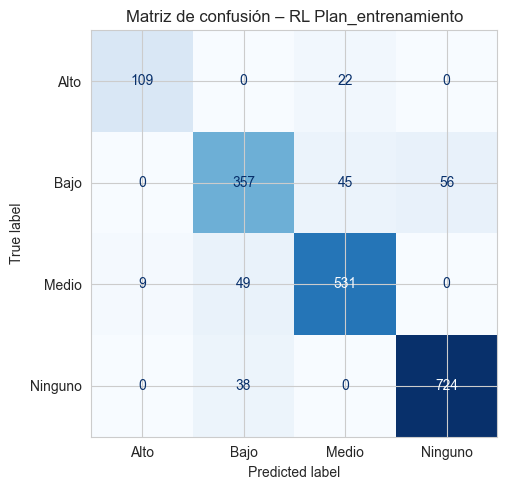

In [21]:
best_rl_entren = grid_rl_entren.best_estimator_
y_entren_pred_rl = best_rl_entren.predict(X_test)

print('=== Reporte de clasificación – RL Plan_entrenamiento ===')
print(classification_report(y_entren_test, y_entren_pred_rl))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_entren_test, y_entren_pred_rl,
                                         ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión – RL Plan_entrenamiento')
plt.tight_layout()
plt.show()

### 2.2 Modelo de regresión logística para 'Plan_nutricion'

In [22]:
grid_rl_nutri = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=param_grid_rl,
    cv=kfold,
    scoring='f1_macro',
    n_jobs=-1
)
grid_rl_nutri.fit(X_train, y_nutri_train)

print('Mejores hiperparámetros:', grid_rl_nutri.best_params_)
print(f'Mejor F1_macro en CV: {grid_rl_nutri.best_score_:.4f}')


Mejores hiperparámetros: {'modelo__C': 1, 'modelo__penalty': 'l1', 'modelo__solver': 'saga'}
Mejor F1_macro en CV: 0.7888


=== Reporte de clasificación – RL Plan_nutricion ===
               precision    recall  f1-score   support

   Balanceado       0.86      0.86      0.86       837
       Basico       0.70      0.68      0.69       467
Especializado       0.70      0.59      0.64       108
     Sin plan       0.87      0.91      0.89       528

     accuracy                           0.81      1940
    macro avg       0.78      0.76      0.77      1940
 weighted avg       0.81      0.81      0.81      1940



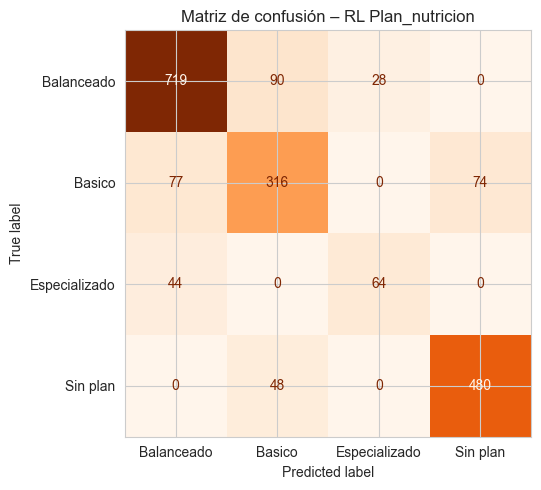

In [23]:
best_rl_nutri = grid_rl_nutri.best_estimator_
y_nutri_pred_rl = best_rl_nutri.predict(X_test)

print('=== Reporte de clasificación – RL Plan_nutricion ===')
print(classification_report(y_nutri_test, y_nutri_pred_rl))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_nutri_test, y_nutri_pred_rl,
                                         ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Matriz de confusión – RL Plan_nutricion')
plt.tight_layout()
plt.show()

## 3. Modelo de árboles de decisión
Ahora entrenamos **dos árboles de decisión** con los mismos objetivos. 

In [24]:
pipeline_dt = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid_dt = {
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_depth': [5, 10, 15, 20, None],
    'modelo__min_samples_split': [2, 10, 20],
    'modelo__min_samples_leaf': [1, 5, 10]
}

### 3.1 Árbol de decisión para 'Plan_entrenamiento'


In [25]:
grid_dt_entren = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=kfold,
    scoring='f1_macro',
    n_jobs=-1
)
grid_dt_entren.fit(X_train, y_entren_train)

print('Mejores hiperparámetros:', grid_dt_entren.best_params_)
print(f'Mejor F1_macro en CV: {grid_dt_entren.best_score_:.4f}')

Mejores hiperparámetros: {'modelo__criterion': 'gini', 'modelo__max_depth': 5, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}
Mejor F1_macro en CV: 0.9994


=== Reporte de clasificación – DT Plan_entrenamiento ===
              precision    recall  f1-score   support

        Alto       0.99      1.00      1.00       131
        Bajo       1.00      1.00      1.00       458
       Medio       1.00      1.00      1.00       589
     Ninguno       1.00      1.00      1.00       762

    accuracy                           1.00      1940
   macro avg       1.00      1.00      1.00      1940
weighted avg       1.00      1.00      1.00      1940



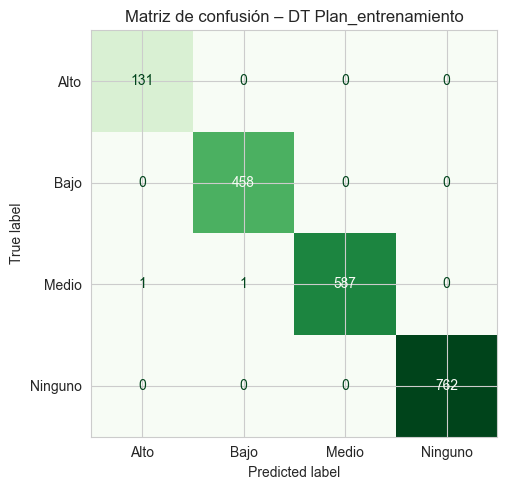

In [26]:
best_dt_entren = grid_dt_entren.best_estimator_
y_entren_pred_dt = best_dt_entren.predict(X_test)

print('=== Reporte de clasificación – DT Plan_entrenamiento ===')
print(classification_report(y_entren_test, y_entren_pred_dt))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_entren_test, y_entren_pred_dt,
                                         ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Matriz de confusión – DT Plan_entrenamiento')
plt.tight_layout()
plt.show()

### 3.2 Árbol de decisión para 'Plan_nutricion'

In [27]:
grid_dt_nutri = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=kfold,
    scoring='f1_macro',
    n_jobs=-1
)
grid_dt_nutri.fit(X_train, y_nutri_train)

print('Mejores hiperparámetros:', grid_dt_nutri.best_params_)
print(f'Mejor F1_macro en CV: {grid_dt_nutri.best_score_:.4f}')

Mejores hiperparámetros: {'modelo__criterion': 'gini', 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}
Mejor F1_macro en CV: 0.9958


=== Reporte de clasificación – DT Plan_nutricion ===
               precision    recall  f1-score   support

   Balanceado       1.00      1.00      1.00       837
       Basico       0.99      1.00      0.99       467
Especializado       0.99      0.99      0.99       108
     Sin plan       1.00      1.00      1.00       528

     accuracy                           1.00      1940
    macro avg       0.99      1.00      1.00      1940
 weighted avg       1.00      1.00      1.00      1940



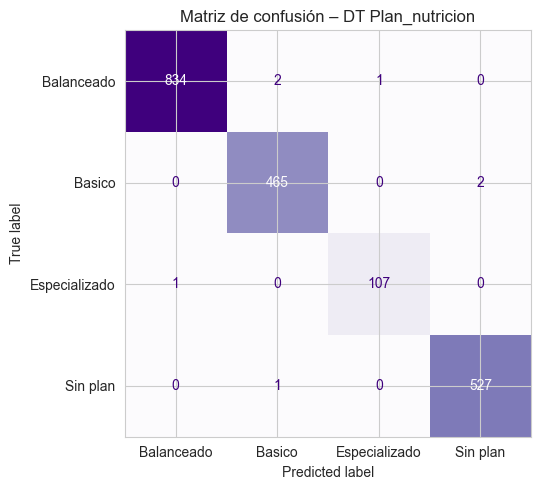

In [28]:
best_dt_nutri = grid_dt_nutri.best_estimator_
y_nutri_pred_dt = best_dt_nutri.predict(X_test)

print('=== Reporte de clasificación – DT Plan_nutricion ===')
print(classification_report(y_nutri_test, y_nutri_pred_dt))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_nutri_test, y_nutri_pred_dt,
                                         ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Matriz de confusión – DT Plan_nutricion')
plt.tight_layout()
plt.show()

### 3.3 Visualización de los árboles (primeros niveles)

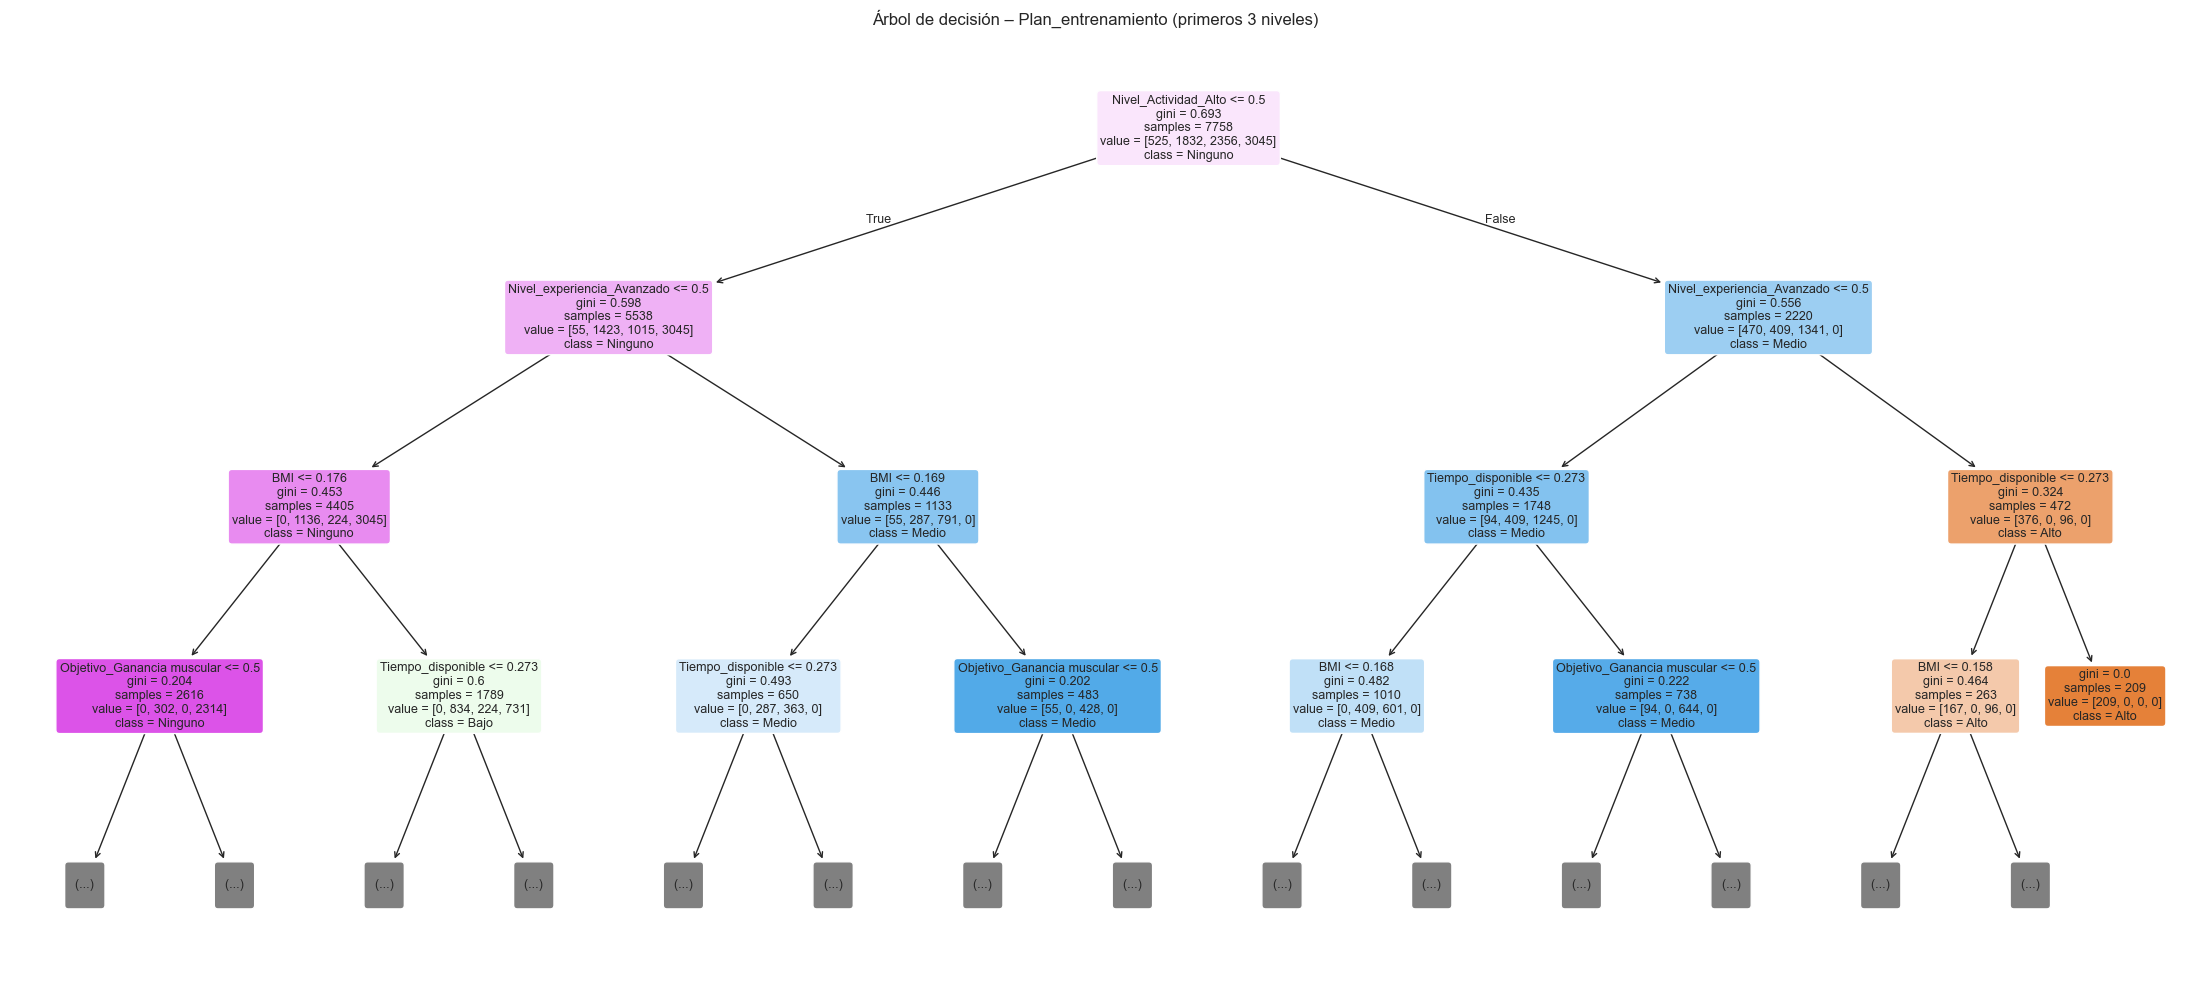

In [29]:
def get_feature_names(pipeline):
    prep = pipeline.named_steps['preprocesador']
    names = []
    names.extend(prep.transformers_[0][2])  # numéricas
    ohe = prep.transformers_[1][1]
    names.extend(ohe.get_feature_names_out(prep.transformers_[1][2]))  # cat
    names.extend(prep.transformers_[2][2])  # binarias
    return np.array(names)

feat_names = get_feature_names(best_dt_entren)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(best_dt_entren.named_steps['modelo'],
          feature_names=feat_names,
          class_names=best_dt_entren.named_steps['modelo'].classes_,
          filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title('Árbol de decisión – Plan_entrenamiento (primeros 3 niveles)')
plt.tight_layout()
plt.show()

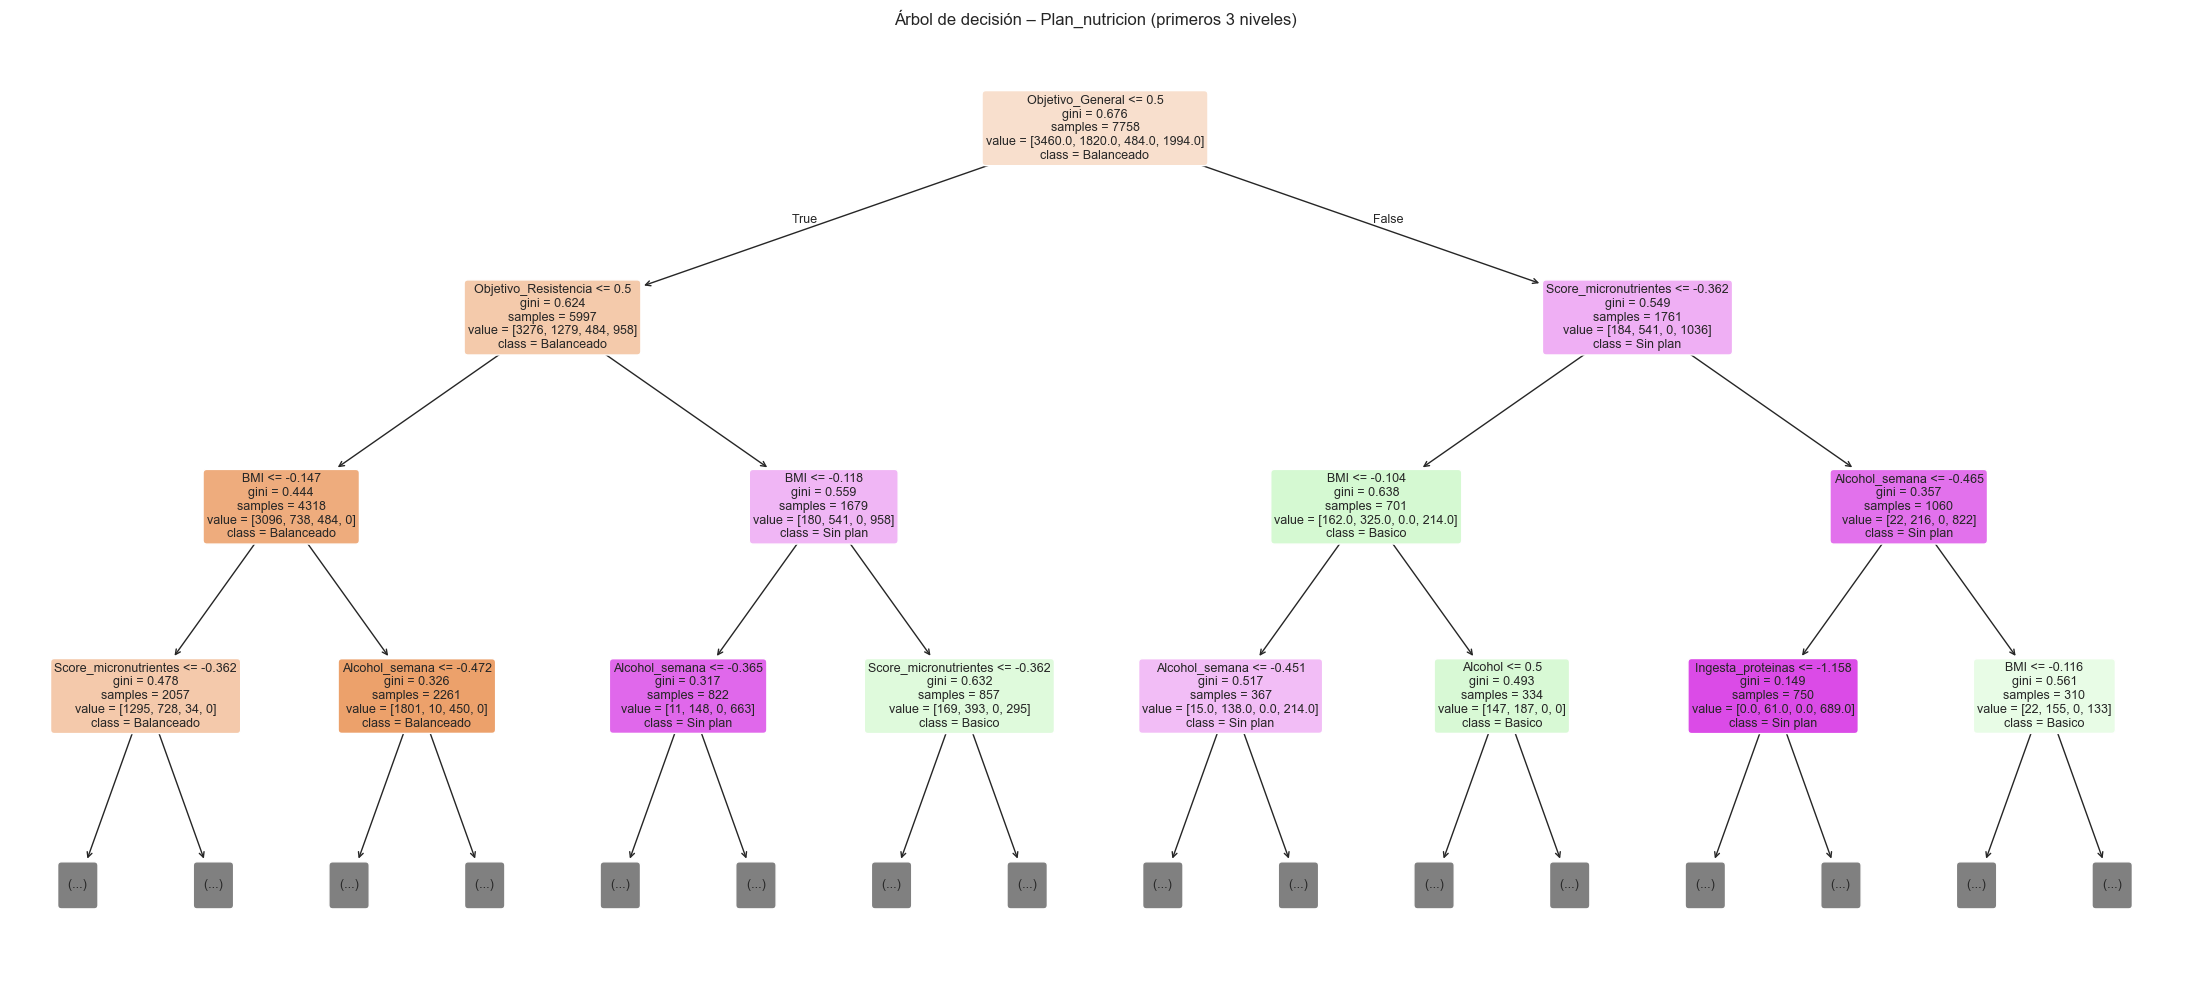

In [30]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(best_dt_nutri.named_steps['modelo'],
          feature_names=feat_names,
          class_names=best_dt_nutri.named_steps['modelo'].classes_,
          filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title('Árbol de decisión – Plan_nutricion (primeros 3 niveles)')
plt.tight_layout()
plt.show()

## 4. Tabla comparativa de los modelos y selección del mejor
Comparamos los 4 modelos sobre el **conjunto de test** usando precision_macro, 'recall_macro' y 'f1_macro'. La versión macro otorga el mismo peso a todas las clases, lo cual es adecuado dado el desbalance observado.

In [31]:
def obtener_metricas(y_true, y_pred, nombre):
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-score (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

resultados = [
    obtener_metricas(y_entren_test, y_entren_pred_rl, 'RL - Plan_entrenamiento'),
    obtener_metricas(y_entren_test, y_entren_pred_dt, 'DT - Plan_entrenamiento'),
    obtener_metricas(y_nutri_test,  y_nutri_pred_rl,  'RL - Plan_nutricion'),
    obtener_metricas(y_nutri_test,  y_nutri_pred_dt,  'DT - Plan_nutricion'),
]
tabla = pd.DataFrame(resultados).set_index('Modelo').round(4)
display(tabla)

,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
Modelo,,,,
RL - Plan_entrenamiento,0.8871,0.8860,0.8658,0.8752
DT - Plan_entrenamiento,0.9990,0.9976,0.9992,0.9984
RL - Plan_nutricion,0.8139,0.7785,0.7593,0.7677
DT - Plan_nutricion,0.9964,0.9948,0.9952,0.9950


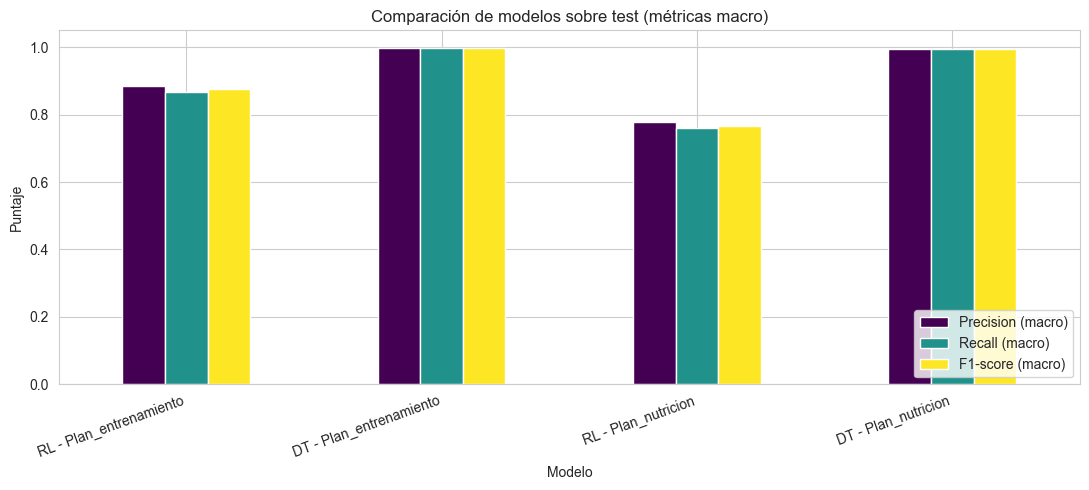

In [32]:
tabla_plot = tabla[['Precision (macro)', 'Recall (macro)', 'F1-score (macro)']]
ax = tabla_plot.plot(kind='bar', figsize=(11, 5), colormap='viridis')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Puntaje')
ax.set_title('Comparación de modelos sobre test (métricas macro)')
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 4.1 Argumentación de la selección del mejor modelo

**Para 'Plan_entrenamiento':** el modelo ganador es el **árbol de decisión**, que supera claramente a la regresión logística en F1-macro. La diferencia se explica porque el árbol captura **interacciones no lineales** entre variables (por ejmeplo si el nivel de actividad es Alto y el objetivo es Ganancia muscular, entonces el plan suele ser Alto), que un modelo lineal no puede representar con la misma facilidad.

**Para 'Plan_nutricion':** igualmente el **árbol de decisión** resulta mejor por el mismo motivo.

**Observación importante:** el F1-macro extremadamente alto del árbol (muy cercano a 1.0) sugiere que las etiquetas originales fueron asignadas mediante reglas determinísticas. El árbol está recuperando esas reglas casi perfectamente. La regresión logística, al estar restringida a fronteras lineales, no alcanza a reproducir esas reglas combinatorias, pero ofrece mayor interpretabilidad en términos de efectos marginales. En un escenario real con ruido en las etiquetas, esta brecha de desempeño sería menor.

**Conclusión:** para **producción** seleccionaríamos el árbol de decisión por su mejor desempeño y para **análisis** la regresión logística sigue siendo valiosa como complemento.


## 5. Identificación de las variables más relevantes
Comparamos la importancia de las variables según cada modelo:

- **Regresión logística**: magnitud de los **coeficientes** en valor absoluto. Como tenemos 4 clases, promediamos '|coef|' a través de las clases para obtener una importancia global por variable.
- **Árboles de decisión**: atributo 'feature_importances_', basado en la reducción promedio de impureza (Gini/entropía) aportada por cada variable en las divisiones.



In [33]:
def importancia_rl(pipeline, feat_names, variables_originales):
    '''Importancia global agrupada por variable original (suma de |coef| promediados entre clases).'''
    coefs = np.abs(pipeline.named_steps['modelo'].coef_).mean(axis=0)
    df_imp = pd.DataFrame({'feature': feat_names, 'imp': coefs})

    def map_to_var(f):
        for v in variables_originales:
            if f == v or f.startswith(v + '_'):
                return v
        return f
    df_imp['variable'] = df_imp['feature'].apply(map_to_var)
    return df_imp.groupby('variable')['imp'].sum().sort_values(ascending=False)

def importancia_dt(pipeline, feat_names, variables_originales):
    imps = pipeline.named_steps['modelo'].feature_importances_
    df_imp = pd.DataFrame({'feature': feat_names, 'imp': imps})

    def map_to_var(f):
        for v in variables_originales:
            if f == v or f.startswith(v + '_'):
                return v
        return f
    df_imp['variable'] = df_imp['feature'].apply(map_to_var)
    return df_imp.groupby('variable')['imp'].sum().sort_values(ascending=False)

vars_originales = numericas + categoricas + binarias
feat_names = get_feature_names(best_rl_entren)

### 5.1 Variables más relevantes para 'Plan_entrenamiento'

In [35]:
imp_rl_entren = importancia_rl(best_rl_entren, feat_names, vars_originales)
imp_dt_entren = importancia_dt(best_dt_entren, feat_names, vars_originales)

comp_entren = pd.concat([
    imp_rl_entren.rename('RL (|coef| promedio)'),
    imp_dt_entren.rename('DT (feature_importance)')
], axis=1).fillna(0)


comp_entren['Rank RL'] = comp_entren['RL (|coef| promedio)'].rank(ascending=False).astype(int)
comp_entren['Rank DT'] = comp_entren['DT (feature_importance)'].rank(ascending=False).astype(int)
comp_entren = comp_entren.sort_values('Rank DT')
display(comp_entren.round(4))

,RL (|coef| promedio),DT (feature_importance),Rank RL,Rank DT
variable,,,,
Objetivo,10.3996,0.2729,3,1
Nivel_experiencia,22.9821,0.2105,1,2
Tiempo_disponible,3.2647,0.1978,4,3
BMI,1.4556,0.1639,6,4
Nivel_Actividad,22.8423,0.1548,2,5
Cantidad_equipo,0.0446,0.0000,22,15
Ingesta_agua,0.0567,0.0000,21,15
Horas_sueno,0.0621,0.0000,20,15
Problemas_digestivos,0.0642,0.0000,19,15


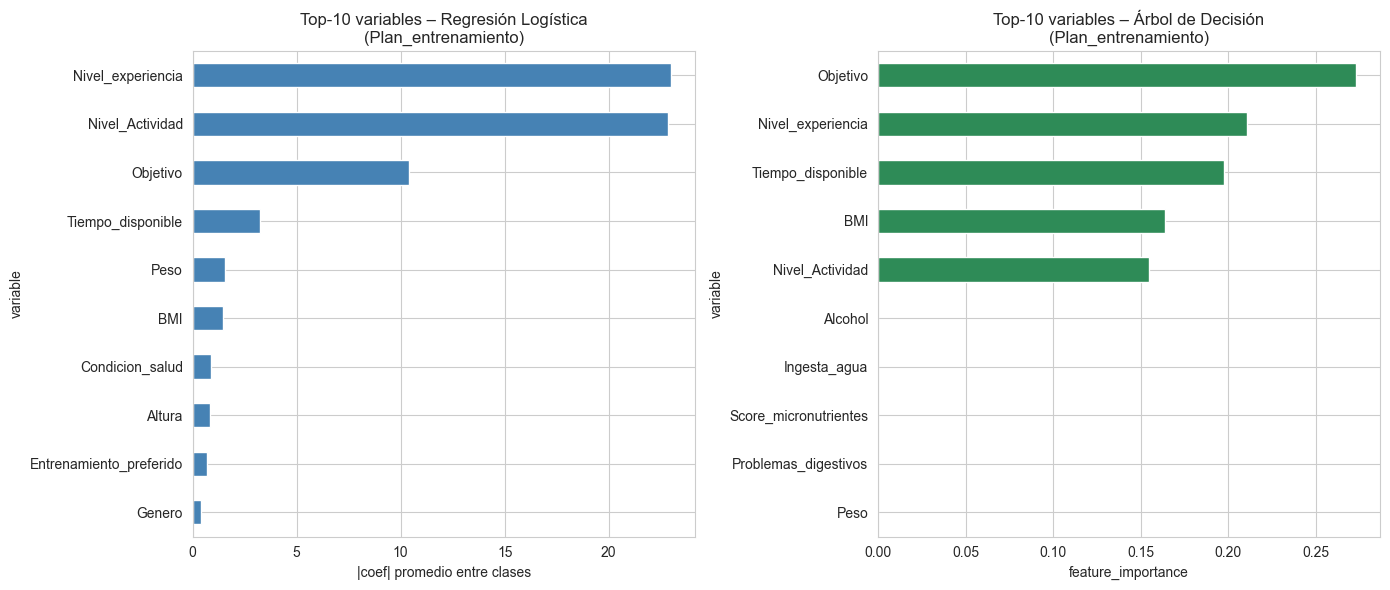

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

imp_rl_entren.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Top-10 variables – Regresión Logística\n(Plan_entrenamiento)')
axes[0].set_xlabel('|coef| promedio entre clases')

imp_dt_entren.head(10).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].invert_yaxis()
axes[1].set_title('Top-10 variables – Árbol de Decisión\n(Plan_entrenamiento)')
axes[1].set_xlabel('feature_importance')

plt.tight_layout()
plt.show()

### 5.2 Variables más relevantes para 'Plan_nutricion'

In [37]:
imp_rl_nutri = importancia_rl(best_rl_nutri, feat_names, vars_originales)
imp_dt_nutri = importancia_dt(best_dt_nutri, feat_names, vars_originales)

comp_nutri = pd.concat([
    imp_rl_nutri.rename('RL (|coef| promedio)'),
    imp_dt_nutri.rename('DT (feature_importance)')
], axis=1).fillna(0)

comp_nutri['Rank RL'] = comp_nutri['RL (|coef| promedio)'].rank(ascending=False).astype(int)
comp_nutri['Rank DT'] = comp_nutri['DT (feature_importance)'].rank(ascending=False).astype(int)
comp_nutri = comp_nutri.sort_values('Rank DT')
display(comp_nutri.round(4))

,RL (|coef| promedio),DT (feature_importance),Rank RL,Rank DT
variable,,,,
Objetivo,19.5004,0.2712,1,1
Ingesta_proteinas,1.1925,0.1941,5,2
Score_micronutrientes,1.9545,0.1927,4,3
BMI,0.7460,0.1195,7,4
Alcohol,4.3975,0.1120,2,5
Alcohol_semana,0.0881,0.1102,14,6
Condicion_salud,0.7441,0.0003,8,7
Tiempo_disponible,0.0354,0.0000,22,16
Ingesta_agua,0.0417,0.0000,21,16


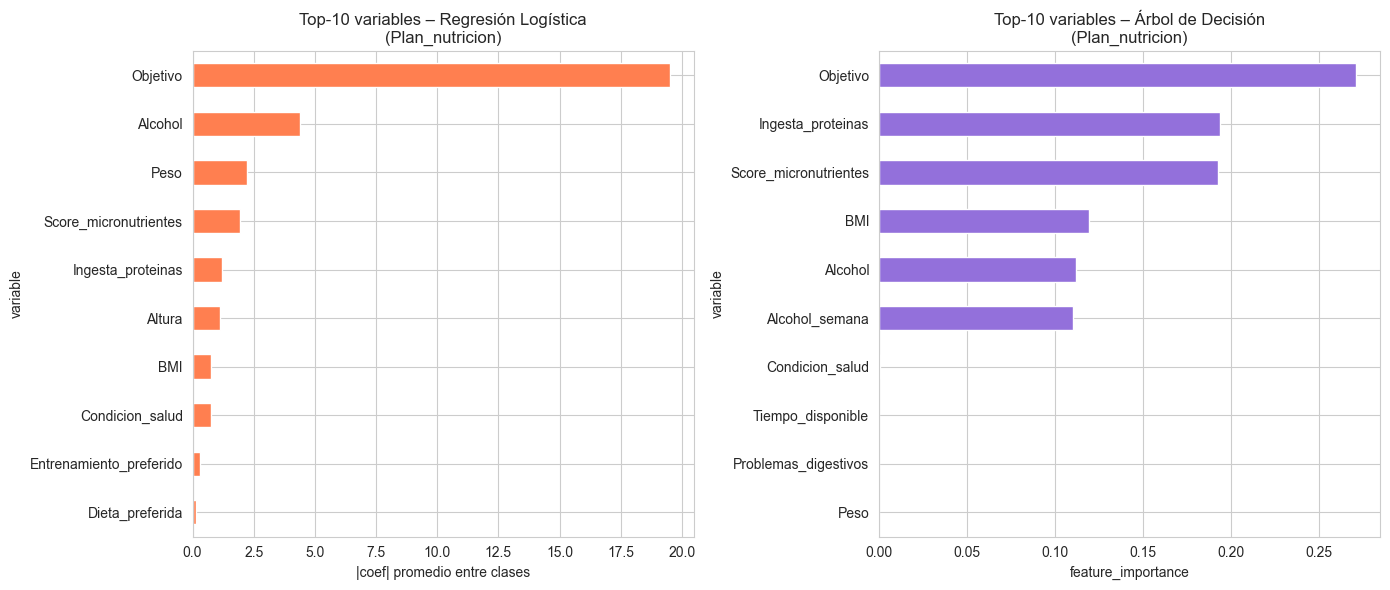

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

imp_rl_nutri.head(10).plot(kind='barh', ax=axes[0], color='coral')
axes[0].invert_yaxis()
axes[0].set_title('Top-10 variables – Regresión Logística\n(Plan_nutricion)')
axes[0].set_xlabel('|coef| promedio entre clases')

imp_dt_nutri.head(10).plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].invert_yaxis()
axes[1].set_title('Top-10 variables – Árbol de Decisión\n(Plan_nutricion)')
axes[1].set_xlabel('feature_importance')

plt.tight_layout()
plt.show()

### 5.3 Discusión de la importancia de variables

**Convergencias entre modelos:** cuando una variable aparece entre las más relevantes **en ambos modelos y en ambos objetivos**, hay evidencia fuerte de su papel en las recomendaciones. Estas son las variables candidatas a explicar la lógica subyacente del sistema de asignación de planes.

**Divergencias entre modelos:** la regresión logística tiende a resaltar variables con **efectos lineales fuertes** (cada unidad adicional empuja en cierta dirección), mientras que los árboles resaltan variables con **buenos puntos de corte discriminantes** (valores umbral que separan grupos). Por eso:

- Una variable numérica con relación no lineal (por ejemplo una U invertida con respecto al plan) puede aparecer alta en el árbol y baja en la regresión logística.
- Una variable binaria con efecto uniforme claro suele aparecer alta en ambos modelos.

**Implicaciones para SmartAlpes:**

1. Las variables que aparecen consistentemente en los tops son las que los entrenadores deberían priorizar al levantar información del cliente.
2. Las variables con importancia cercana a 0 en el árbol y coeficiente cercano a 0 en la regresión logística (tras regularización L1) son candidatas a **eliminar del formulario de ingreso** para agilizar el proceso sin perder poder predictivo.
